# LArXe Light Yield (Liq. #7)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as clrs
import pandas as pd
from glob import glob
import uproot
import sipm.recon.WaveformDataset as wfd
import sipm.util.functions as func
import sipm.util.spectrum as spectrum

plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'xtick.minor.visible': True, 'ytick.minor.visible': True, 'axes.grid': True})

## Read calibration file and get SPE gain

In [2]:
calib = {}
pe_scale = {}
voltages = [92,94,96,98,100]
for volt in voltages:
    calib[volt] = pd.read_hdf('/home/as111/sipm-analysis/data/calibration_liq6_2023-12-13.h5', key=f'{volt}V')
    pe_scale[volt] = calib[volt]['Qavg']/(1-calib[volt]['DiCT'])

## G4DS simulation (Compton scattering + UV photon transport)

['nph_wl_tba0p3;1', 'tpcene;1']
<TH1D (version 3) at 0x15513852fd00>
['nph_wl_tba0p3;1', 'tpcene;1']
<TH1D (version 3) at 0x15513858a670>
['nph_wl_tba0p3;1', 'tpcene;1']
<TH1D (version 3) at 0x15513849ba60>
['nph_wl_tba0p3;1', 'tpcene;1']
<TH1D (version 3) at 0x1551384274c0>


Text(0.5, 1.0, 'Geant-4 Spectra')

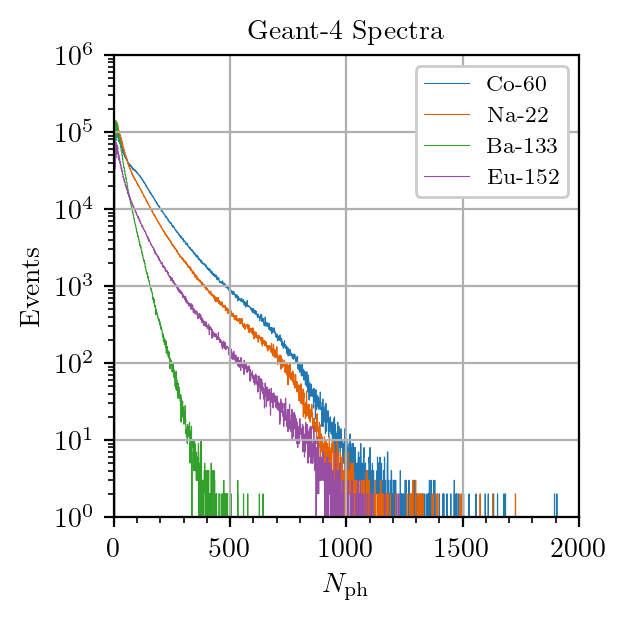

In [3]:
src = {'Co-60':'co60','Na-22':'na22','Ba-133':'ba133','Eu-152':'eu152'}
hist_sim = {}
plt.figure(0,figsize=(3,3))
for S,s in src.items():
	rtf = uproot.open(f'/home/as111/sipm-analysis/data/pe_hist/no_reflection/pu_lar_{s}_hist.root')
	print(rtf.keys())
	try:
		hist_sim[S] = rtf['nph_wl_tba0p3'].to_numpy()
		print(rtf['nph_wl_tba0p3'])
		plt.stairs(hist_sim[S][0],hist_sim[S][1],linewidth=0.4,label=S)
	except uproot.KeyInFileError:
		print(f'{s} no such key')
plt.yscale('log')
plt.xlabel(r'$N_{\rm ph}$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.title('Geant-4 Spectra')

### G4DS Energy Deposition vs Npe, Na-22

/tmp/ipykernel_2833905/625926055.py:24: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.pcolormesh(bins2d_ene, bins2d_wl, hist2d_ene_wl.T, norm=clrs.LogNorm())


(0.0, 1200.0)

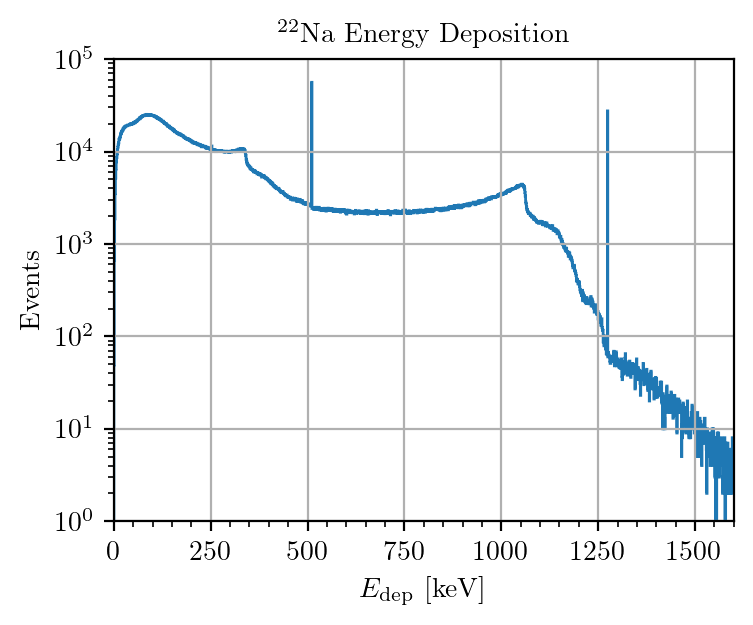

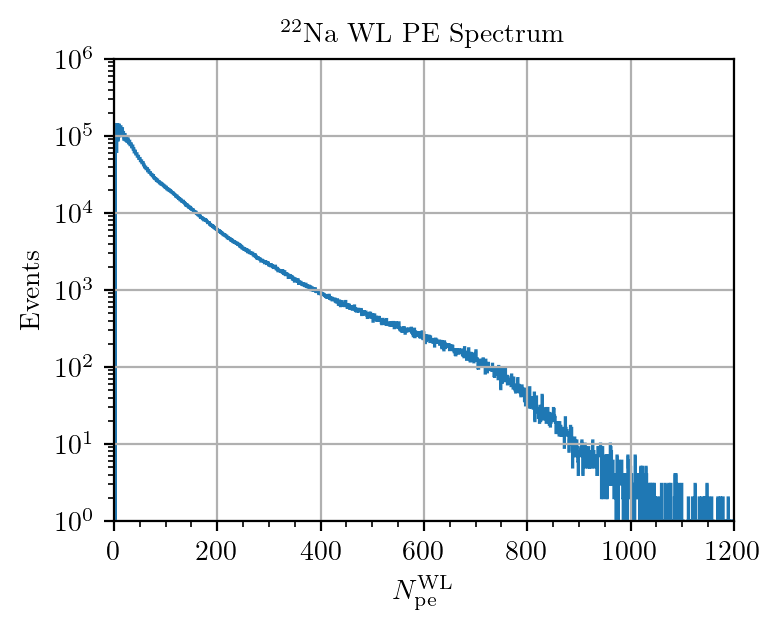

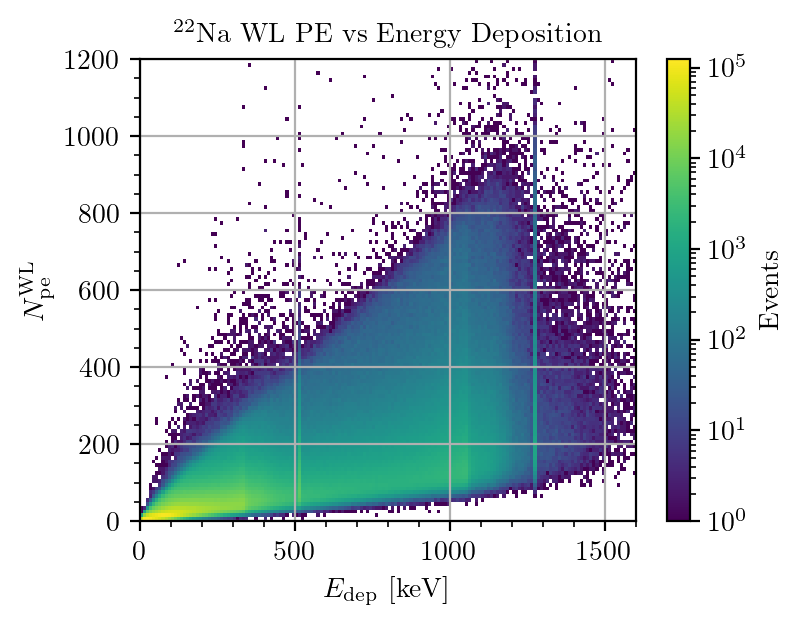

In [4]:
with np.load('/home/as111/sipm-analysis/data/pe_hist/no_reflection/pu_lar_na22_hist.npz') as data:
	hist_ene, bins_ene = data['hist_ene'], data['bins_ene']
	hist_wl, bins_wl = data['hist_wl'], data['bins_wl']
	hist2d_ene_wl, bins2d_ene, bins2d_wl = data['hist2d_ene_wl'], data['bins2d_ene'], data['bins2d_wl']
 
fs = 10
plt.figure(0)
plt.stairs(hist_ene, bins_ene)
plt.yscale('log')
plt.xlabel(r'$E_{\rm dep}$ [keV]',fontsize=fs)
plt.ylabel('Events',fontsize=fs)
plt.title(r'$^{22}\rm Na$' + ' Energy Deposition',fontsize=fs)
plt.xlim(0,1600)

plt.figure(1)
plt.stairs(hist_wl, bins_wl)
plt.yscale('log')
plt.xlabel(r'$N^{\rm WL}_{\rm pe}$',fontsize=fs)
plt.ylabel('Events',fontsize=fs)
plt.title(r'$^{22}\rm Na$' + ' WL PE Spectrum',fontsize=fs)
plt.xlim(0,1200)

plt.figure(2)
plt.pcolormesh(bins2d_ene, bins2d_wl, hist2d_ene_wl.T, norm=clrs.LogNorm())
plt.colorbar(label='Events')
plt.xlabel(r'$E_{\rm dep}$ [keV]',fontsize=fs)
plt.ylabel(r'$N^{\rm WL}_{\rm pe}$',fontsize=fs)
plt.title(r'$^{22}\rm Na$' + ' WL PE vs Energy Deposition',fontsize=fs)
plt.grid()
plt.xlim(0,1600)
plt.ylim(0,1200)

## Detector response model
The number of PE follows the distribution
$$N_{\rm PE} \sim \mathcal{N}(\mu=N_{\rm ph}L_r, \sigma=\sqrt{F\mu}),$$
where $N_{\rm ph}$ is the number of photons arriving at the SiPMs (from G4DS), $L_r\equiv \varepsilon S/S_{\rm sim}$, $\varepsilon$ is the SiPMs' photo-detection efficiency (PDE), $S_{\rm sim}$ is the LAr scintillation yield used in G4DS (probably $1\rm ph/19.5eV=51.3ph/keV$), $S$ is the true scintillation yield ($\approx 40\rm ph/keV$ for pure LAr, to be measured for Xe-doped LAr), and $F$ is the Fano factor of the SiPMs due to correlated avalanches.

## Visualize raw waveforms

trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
trigger_position: 1555
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-05-07/2024-05-07_volt_98_light_scintillation_source_na22_xenon_0_cond_gamma/7/wave0.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-05-07/2024-05-07_volt_98_light_scintillation_source_na22_xenon_0_cond_gamma/7/wave1.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-05-07/2024-05-07_volt_98_light_scintillation_source_na22_xenon_0_cond_gamma/7/wave2.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-05-07/2024-05-07_volt_98_light_scintillation_source_na22_xenon_0_cond_gamma/7/wave3.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-05-07/2024-05-07_volt_98_light_scintillation_source_na22_xenon_0_cond_gamma/7/wave4.dat
10 events
/scratch/gpfs/GALBIATI/data/sipm//xenon_doping/2024-05-07/2024-05-

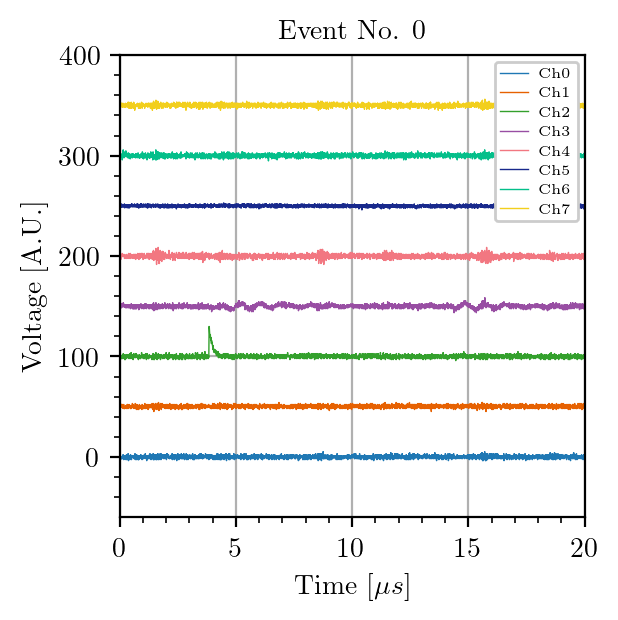

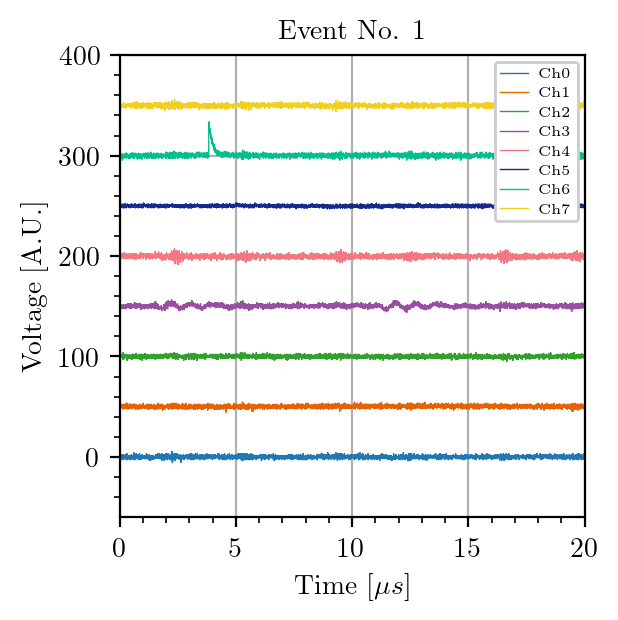

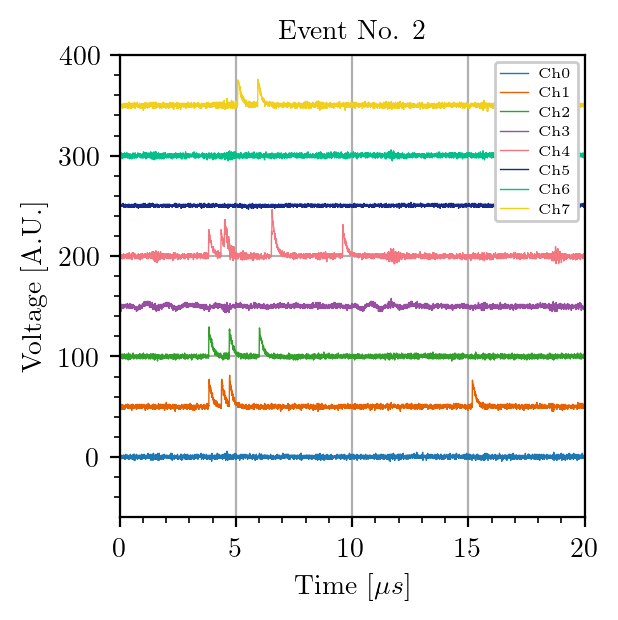

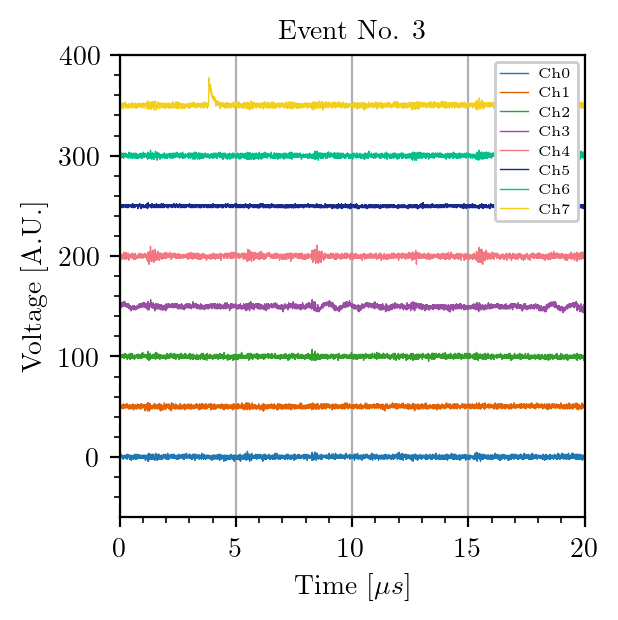

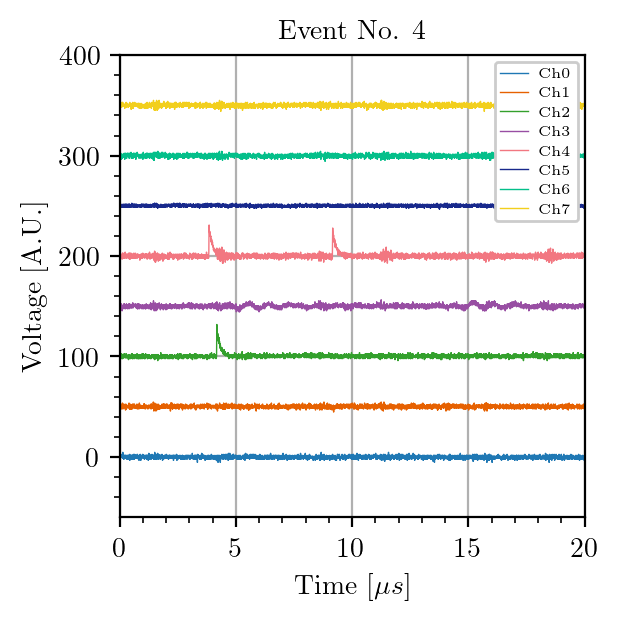

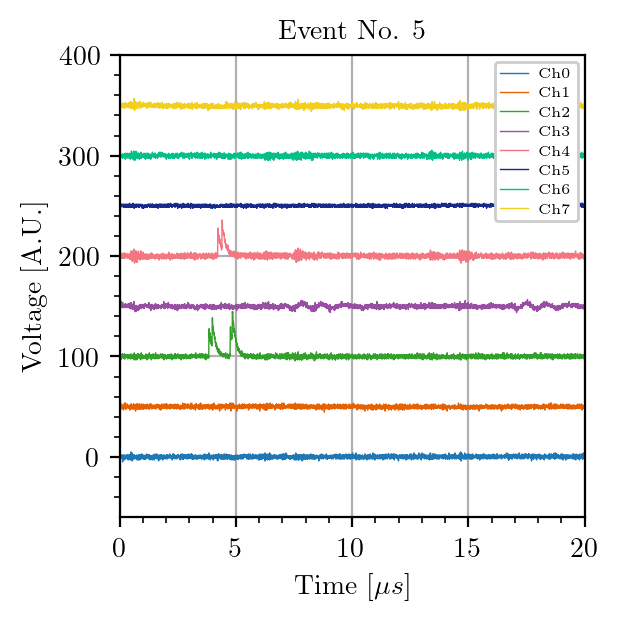

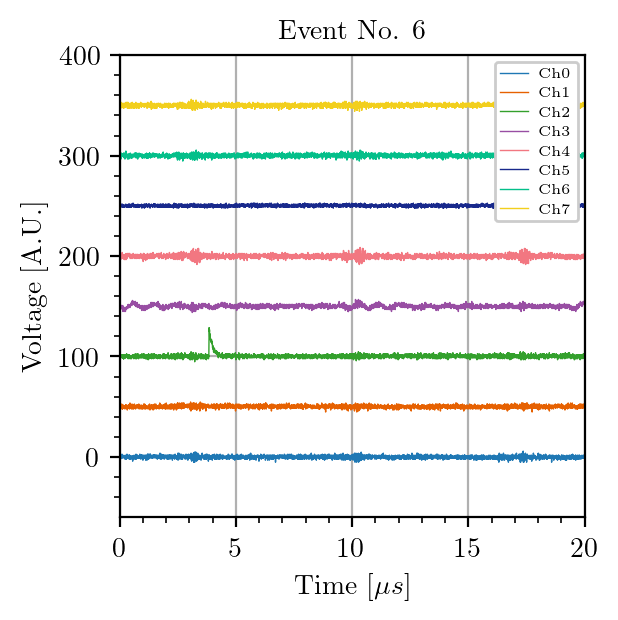

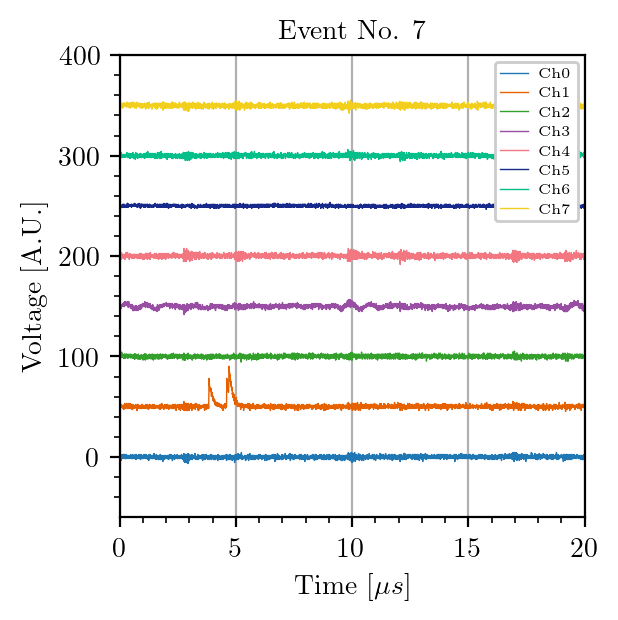

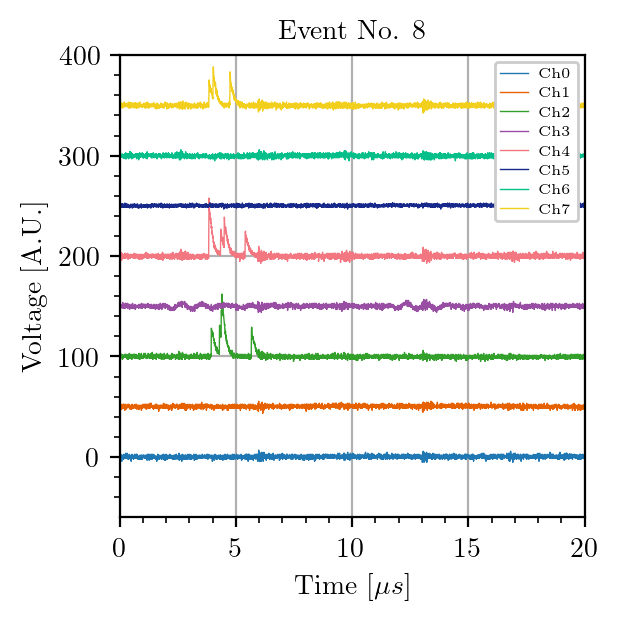

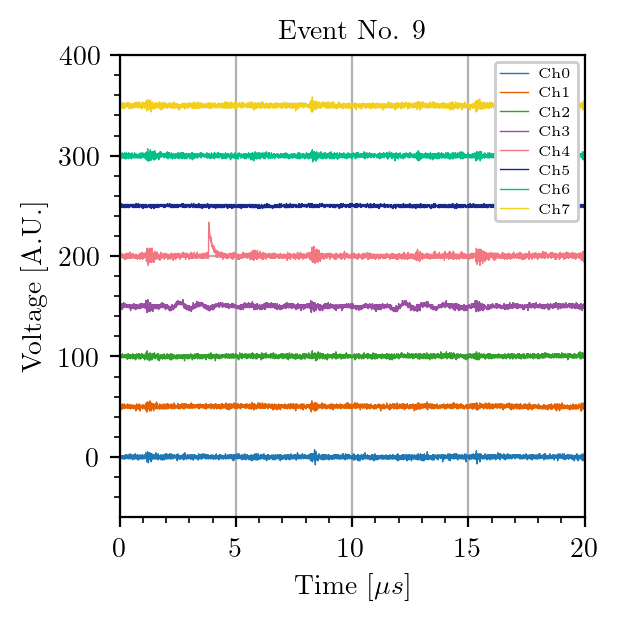

In [5]:
evid = np.arange(0, 10)
dset = wfd.WaveformDataset(
    path='/scratch/gpfs/GALBIATI/data/sipm/xenon_doping/2024-05-07/2024-05-07_volt_98_light_scintillation_source_na22_xenon_0_cond_gamma/7/', 
    pol=-1, 
    channels=range(8))
wfs = []
for ch in np.arange(8):
    wfs.append(dset.ch[ch].get_waveforms(ev=evid, ar_filter=False)[0])
wfs = np.array(wfs)
print(wfs.shape)
for i in range(wfs.shape[1]):
    plt.figure(i, figsize=(3, 3))
    for ch in range(wfs.shape[0]):
        plt.plot(dset.ch[ch].time, wfs[ch,i]+ch*50, label=f'Ch{ch}', linewidth=0.5)
    plt.legend(loc='upper right', fontsize=5)
    plt.xlabel(r'Time [$\mu s$]')
    plt.ylabel(r'Voltage [A.U.]')
    plt.xlim(0, 20)
    plt.ylim(-60, 400)
    plt.title(f'Event No. {evid[i]}')

## Load pre-processed h5

Na-22 data at equilibrium

In [6]:
path = "/scratch/gpfs/GALBIATI/as111/results/"
xe_conc = [0,0.1,0.2,0.3,0.4,0.7,1.0,1.5,2.0,2.7]
cond = [f'Na-22 {x}ppm' for x in xe_conc]
files = [glob(f'{path}*/*cond_gamma*source_na22*xenon_{i}*pulse_liq7.h5') for i in range(len(xe_conc))] 
for f in files:
	print(len(f), f)

20 ['/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run16_scintillation_pulse_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run0_scintillation_pulse_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run12_scintillation_pulse_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run2_scintillation_pulse_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run13_scintillation_pulse_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run4_scintillation_pulse_liq7.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-05-07/2024-05-07_volt_98_l

In [7]:
data = {}
channels = np.arange(-1,8)
volt = 98
date_time = []
for i, c in enumerate(cond):
    data[c], dt = spectrum.load_data(files[i],channels,volt)
    print(f'{c}: {data[c].shape[0]} events {dt}')
    date_time.append(dt) 
print('columns: ', list(data[cond[0]].columns))

Na-22 0ppm: 1005271 events 2024-05-07 13:44:33
Na-22 0.1ppm: 502912 events 2024-05-14 15:31:56
Na-22 0.2ppm: 502858 events 2024-05-16 17:52:03
Na-22 0.3ppm: 502703 events 2024-05-20 16:14:20
Na-22 0.4ppm: 502711 events 2024-05-21 10:47:23
Na-22 0.7ppm: 502984 events 2024-05-23 16:05:20
Na-22 1.0ppm: 502340 events 2024-05-24 10:10:18
Na-22 1.5ppm: 1005781 events 2024-05-28 10:12:28
Na-22 2.0ppm: 502856 events 2024-05-29 09:23:50
Na-22 2.7ppm: 502969 events 2024-05-30 09:09:12
columns:  ['start_datetime', 'end_datetime', 'duration_seconds', 'nch', 'nch_fs', 'nch_nofs', 'total_pe', 'fprompt_0p30us_01234567', 'fprompt_0p30us_0356', 'fprompt_0p30us_1247', 'baseline_mean_0', 'baseline_rms_0', 'integral_0p30us_0', 'integral_10p00us_0', 'fired_0', 'amplitude_0', 'peakpos_0', 'baseline_mean_1', 'baseline_rms_1', 'integral_0p30us_1', 'integral_10p00us_1', 'fired_1', 'amplitude_1', 'peakpos_1', 'baseline_mean_2', 'baseline_rms_2', 'integral_0p30us_2', 'integral_10p00us_2', 'fired_2', 'amplitude_2

## Reconstruct $N_{pe}$ and $f_{prompt}$

In [8]:
# pe count by channel
col_names = ['10p00us','0p30us']
for c in cond:
	for col in col_names:
		for ch in np.arange(8):
			data[c][f'pe_{col}_{ch}'] = data[c][f'integral_{col}_{ch}']/pe_scale[98][ch]

In [9]:
# pe count wl & ww
channels_wl = [1,2,4,7]
channels_ww = [0,3,6]
for c in cond:
	for col in col_names:
		data[c][f'pe_{col}_wl'] = data[c][[f'pe_{col}_{ch}' for ch in channels_wl]].sum(axis=1)
		data[c][f'pe_{col}_ww'] = data[c][[f'pe_{col}_{ch}' for ch in channels_ww]].sum(axis=1)

In [10]:
# fprompt wl
short_name = '0p30us'
long_name = '10p00us'
for c in cond:
    data[c]['fprompt'] = data[c][[f'pe_{short_name}_{ch}' for ch in channels_wl]].sum(axis=1) / data[c][[f'pe_{long_name}_{ch}' for ch in channels_wl]].sum(axis=1)

In [11]:
# top-bottom asymmetry
channels_top = [4,7]
channels_bot = [1,2]
for c in cond:
    top = data[c][[f'pe_10p00us_{ch}' for ch in channels_top]].sum(axis=1)
    bot = data[c][[f'pe_10p00us_{ch}' for ch in channels_bot]].sum(axis=1)
    data[c]['tba'] = (top-bot)/(top+bot)

## Apply RMS cut

In [12]:
rms_threshold = [2.0,2.0,2.0,2.5,2.5,2.0,2.0,2.0]
for c in cond:
    df_bsl_filt = spectrum.get_bsl_filt(data[c],np.arange(8),rms_threshold)
    data[c][df_bsl_filt.columns] = df_bsl_filt
    df_bsl_filt = None

## Fprompt distribution

/tmp/ipykernel_2833905/4026331055.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(h[1],h[2],np.log10(h[0]).T)
/tmp/ipykernel_2833905/4026331055.py:16: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.pcolormesh(h[1],h[2],np.log10(h[0]).T)


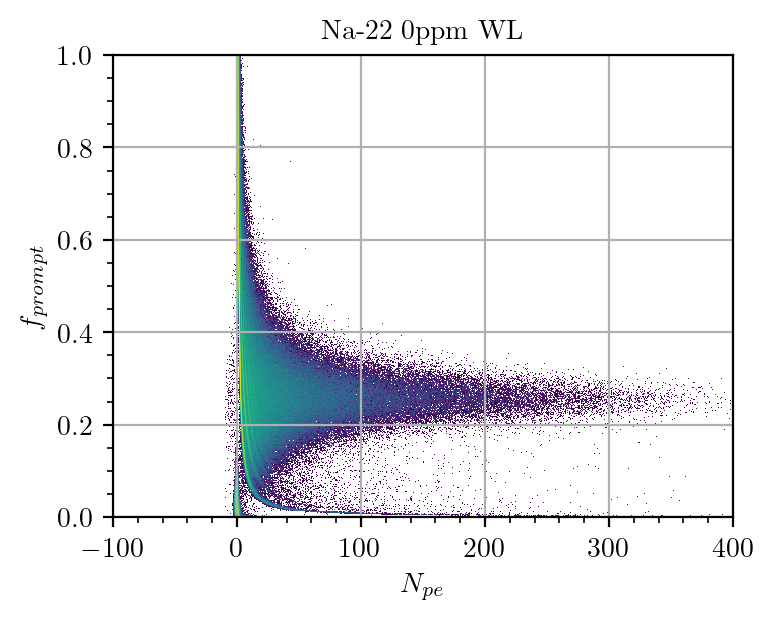

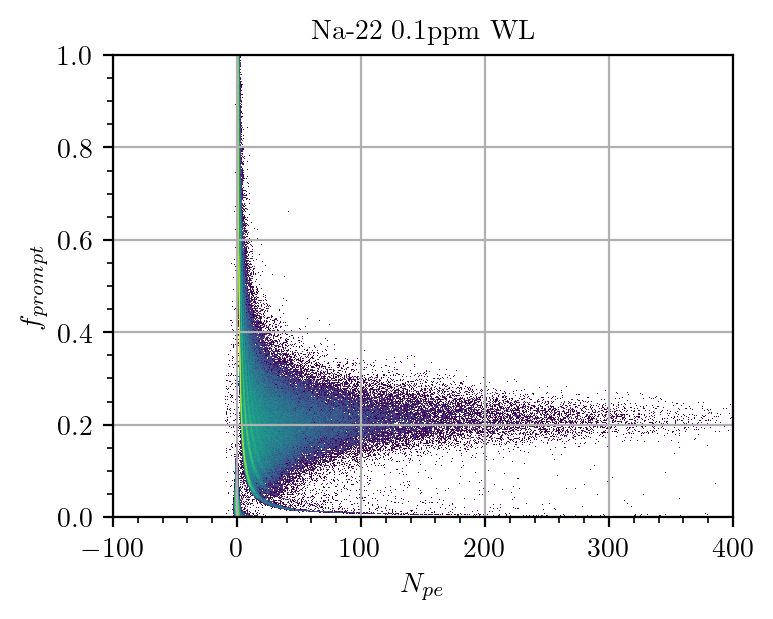

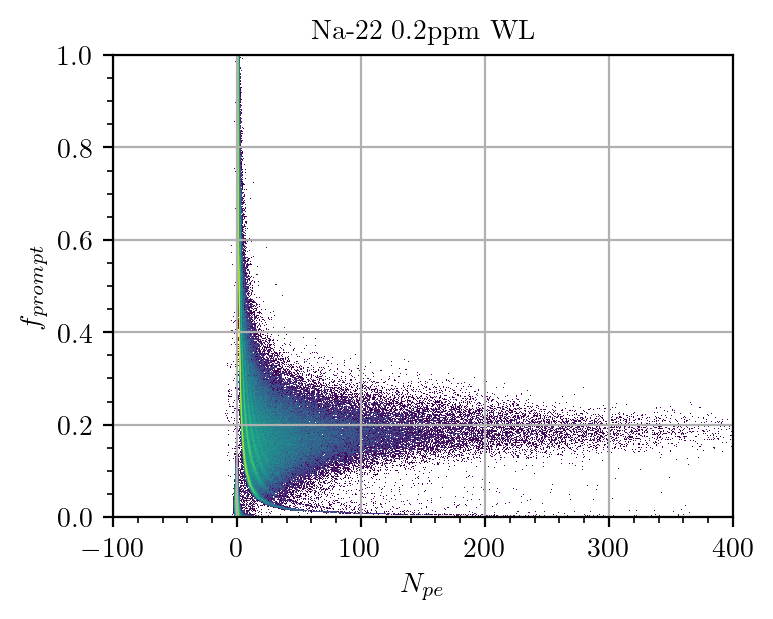

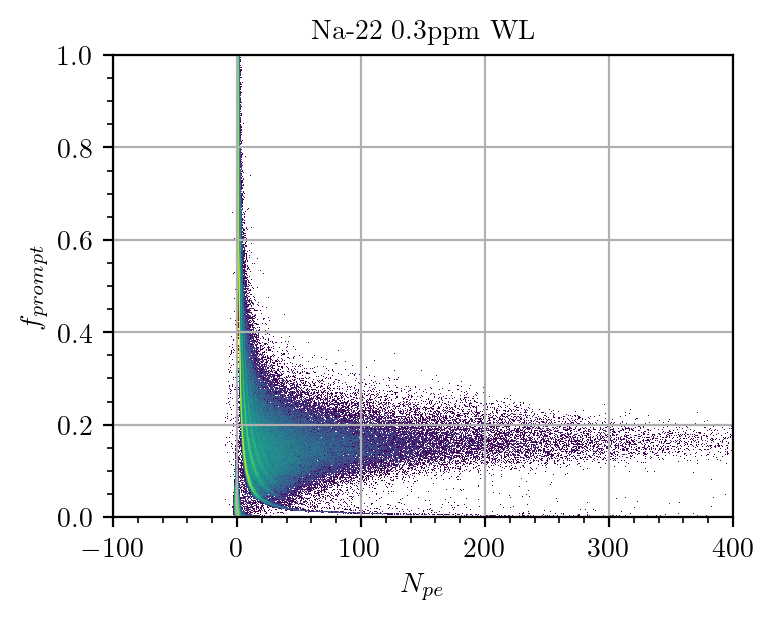

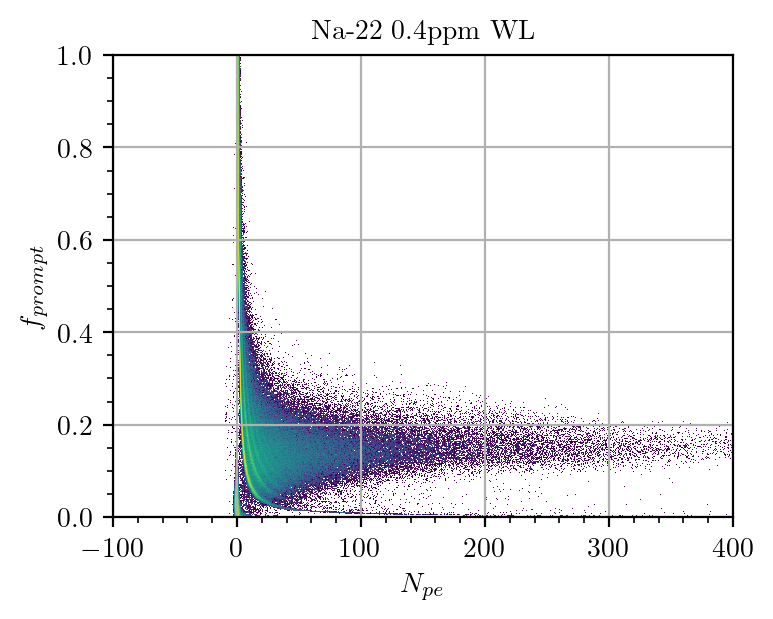

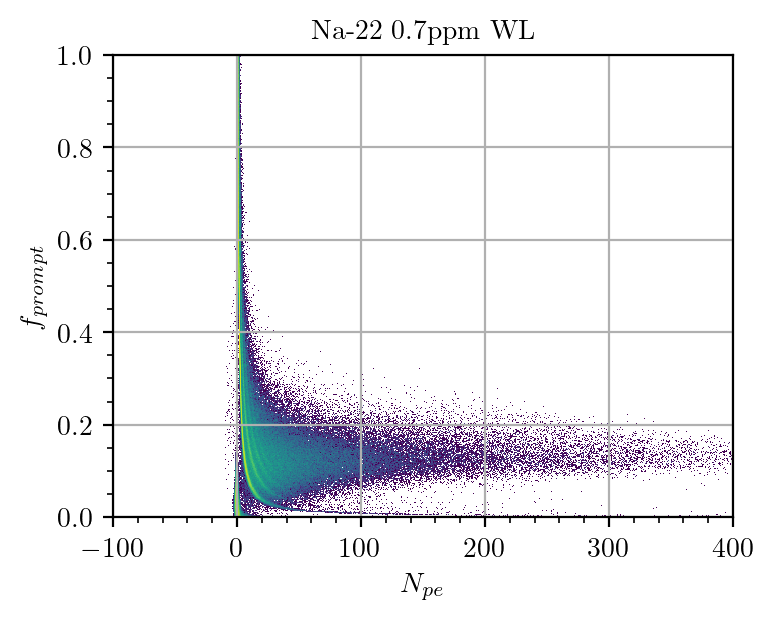

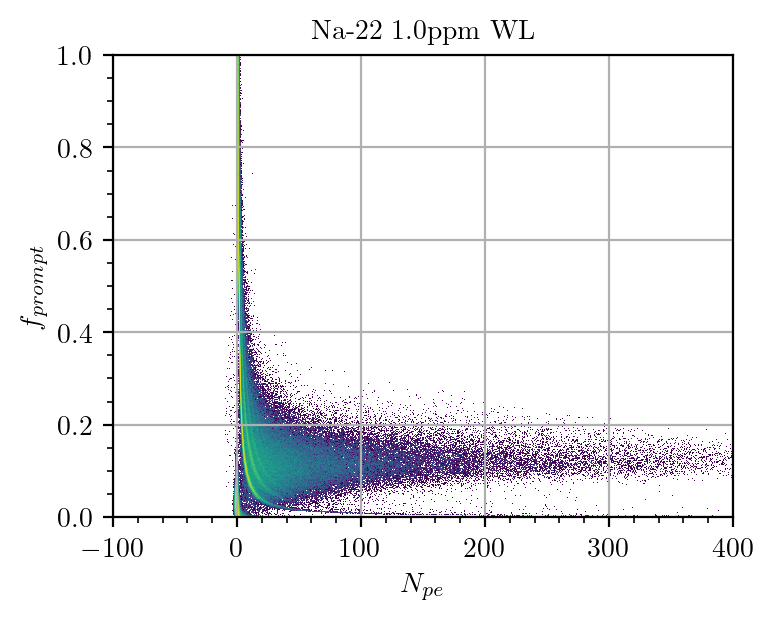

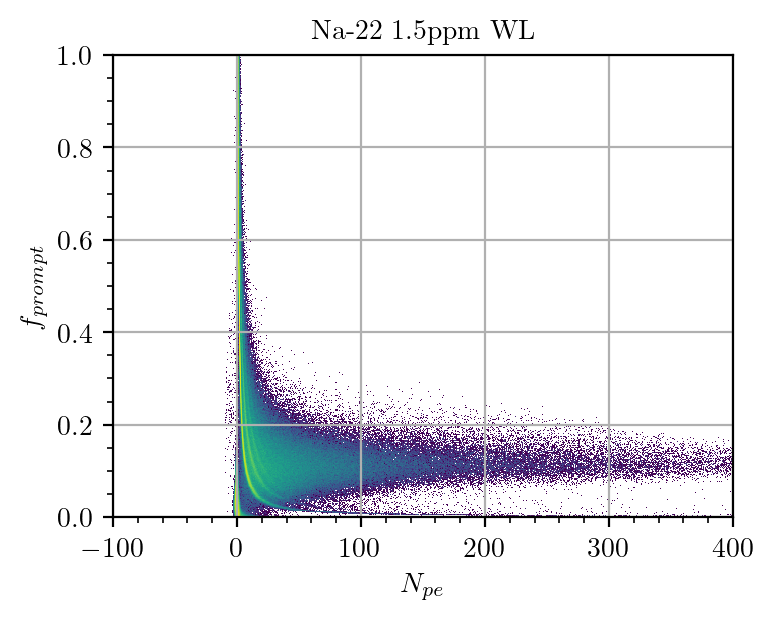

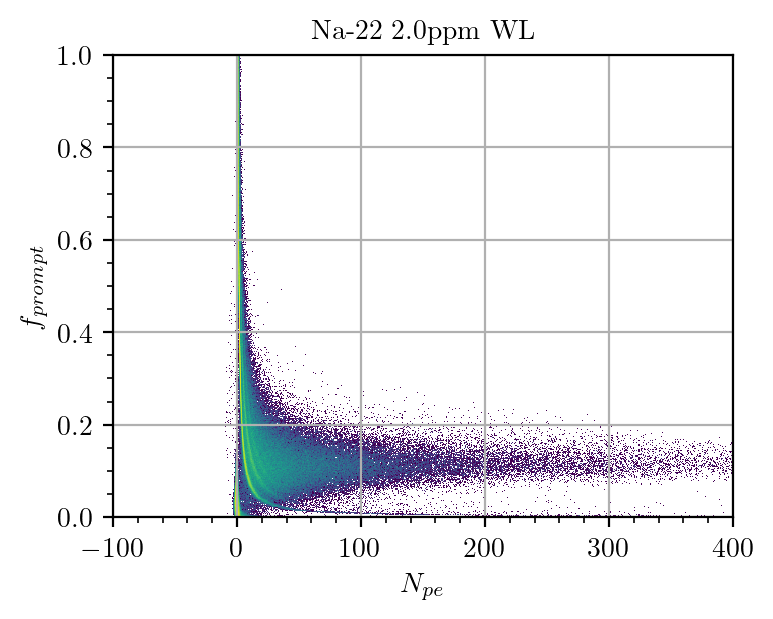

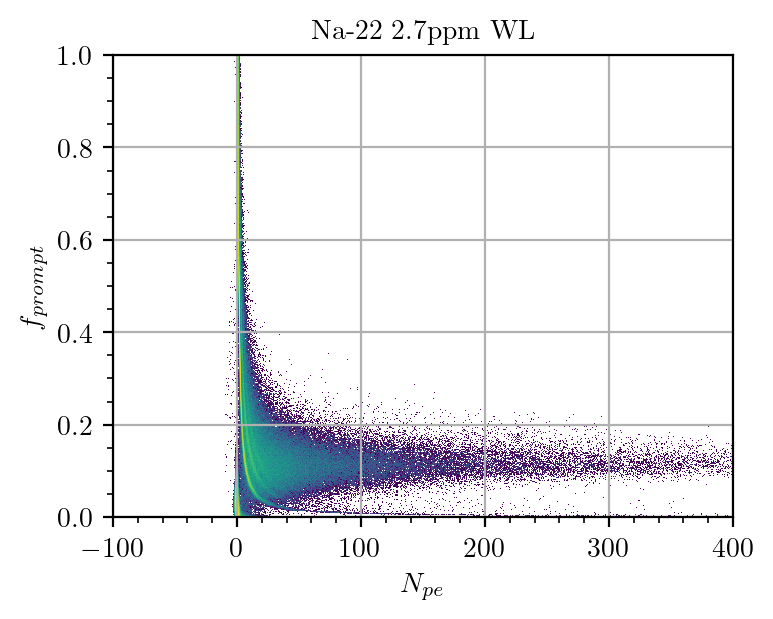

In [13]:
# Initialize Fprompt container
fprompt = {}

# Produce fprompt 2D histograms
binsx = 500
range_minx = -10
range_maxx = 400
binsy = 500
range_miny = 0
range_maxy = 1

for i,c in enumerate(cond):
	plt.figure(i)
	filt = data[c]['bsl_filt'] & (data[c]['amplitude_1']<1200) & (data[c]['amplitude_2']<1200) & (data[c]['amplitude_4']<1200) & (data[c]['amplitude_7']<1200)
	h = np.histogram2d(data[c][filt]['pe_10p00us_wl'],data[c][filt]['fprompt'],bins=[binsx,binsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]])
	plt.pcolormesh(h[1],h[2],np.log10(h[0]).T)
	plt.xlabel(r'$N_{pe}$')
	plt.ylabel(r'$f_{prompt}$')
	plt.title(f'{c} WL')
	plt.grid()

## TBA distribution

/tmp/ipykernel_2833905/985998327.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(h[1],h[2],np.log10(h[0]/(h[0].sum(axis=0))[np.newaxis,:]).T)
/tmp/ipykernel_2833905/985998327.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.pcolormesh(h[1],h[2],np.log10(h[0]/(h[0].sum(axis=0))[np.newaxis,:]).T)


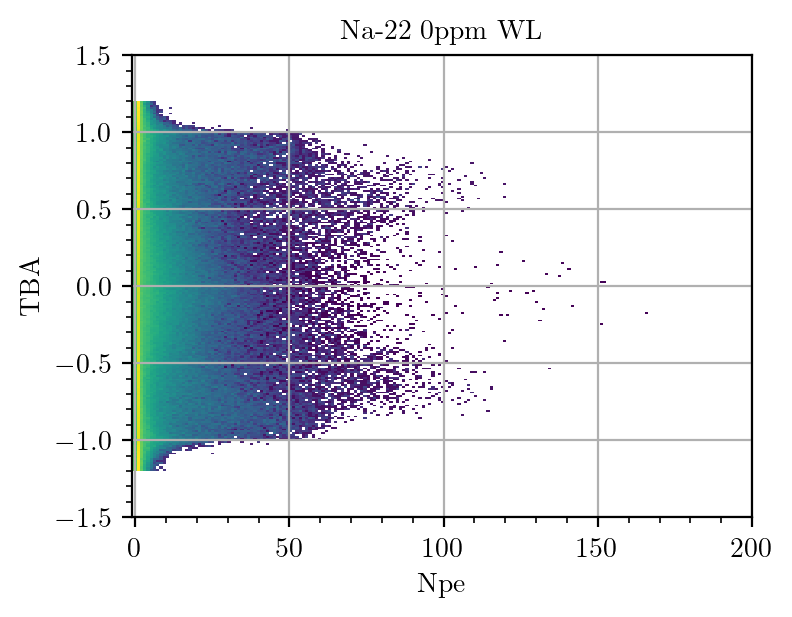

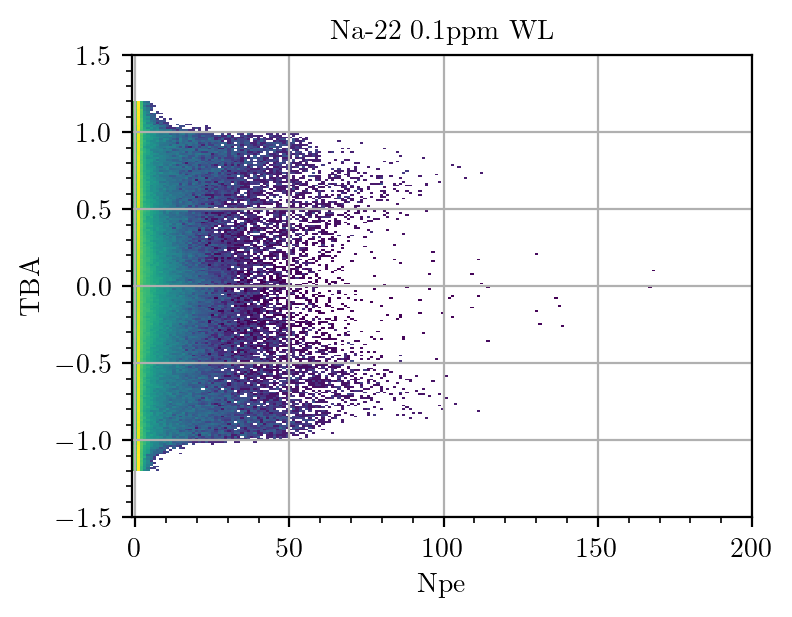

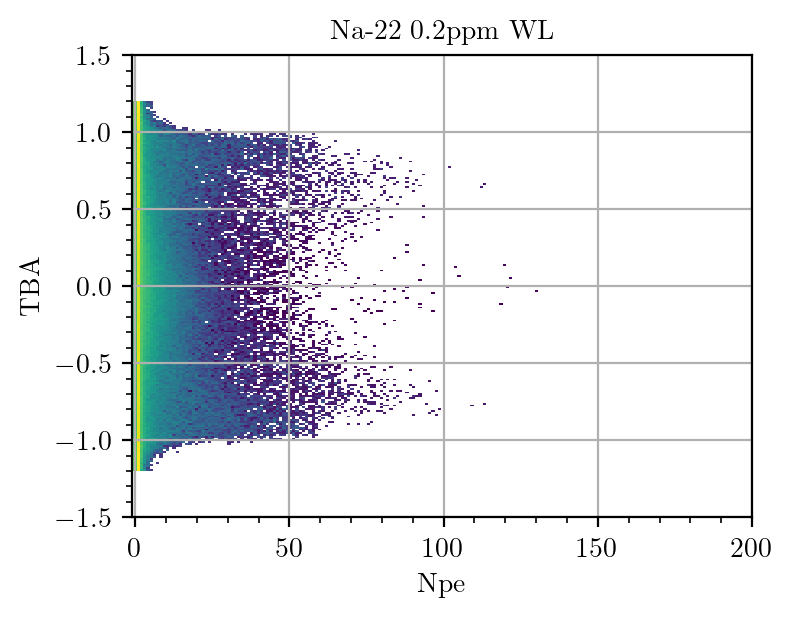

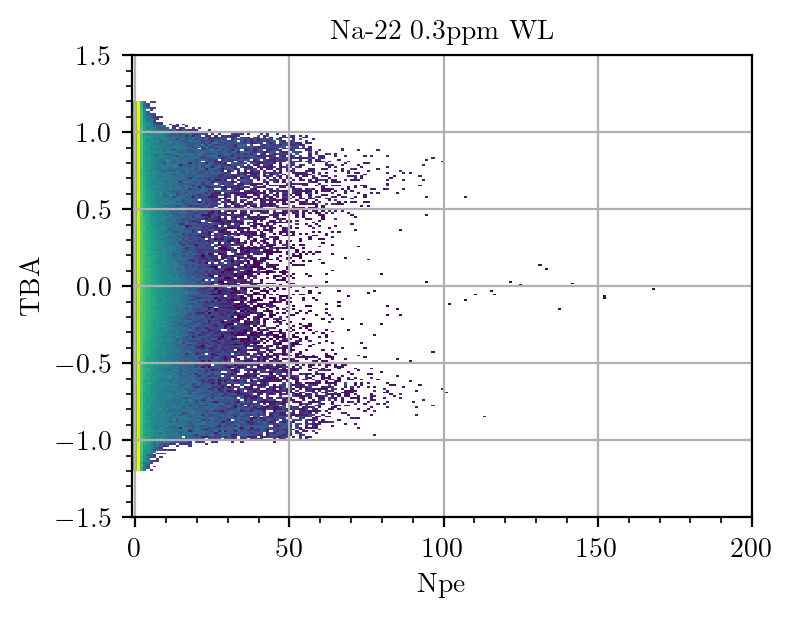

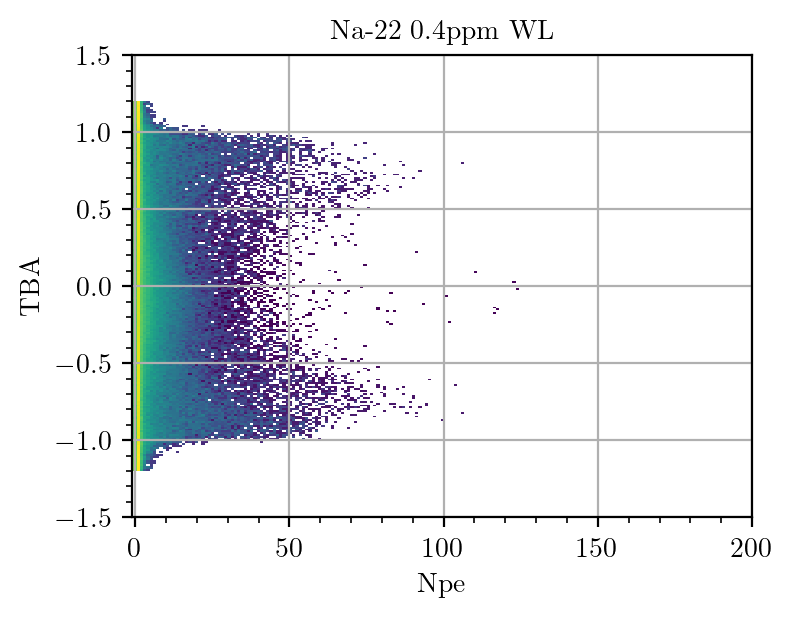

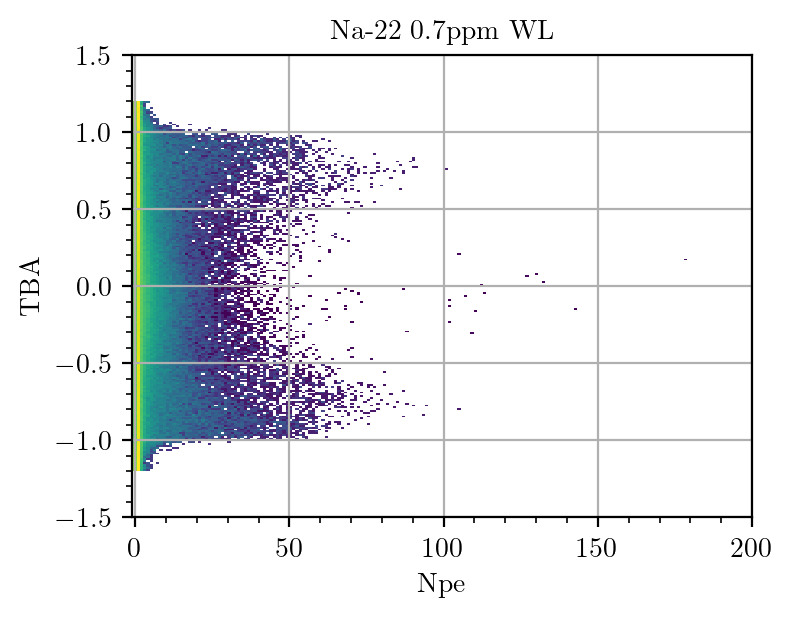

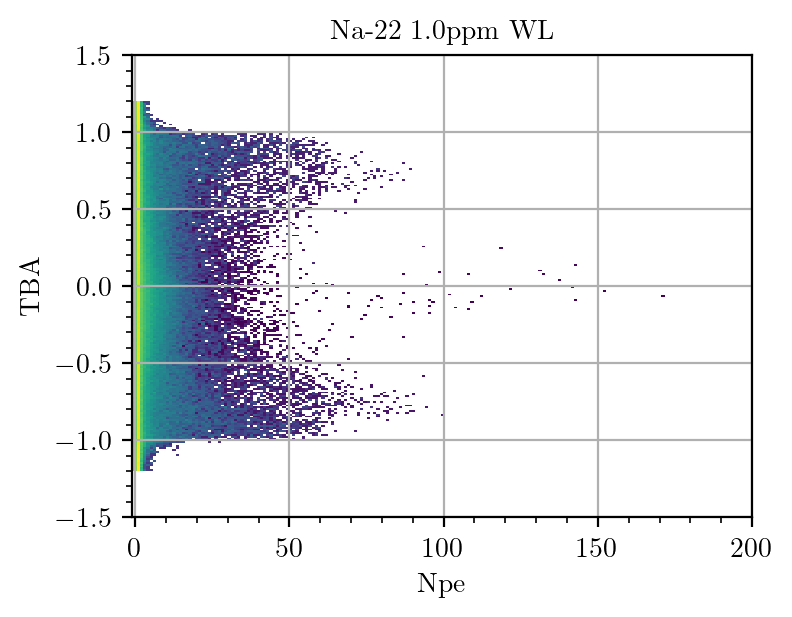

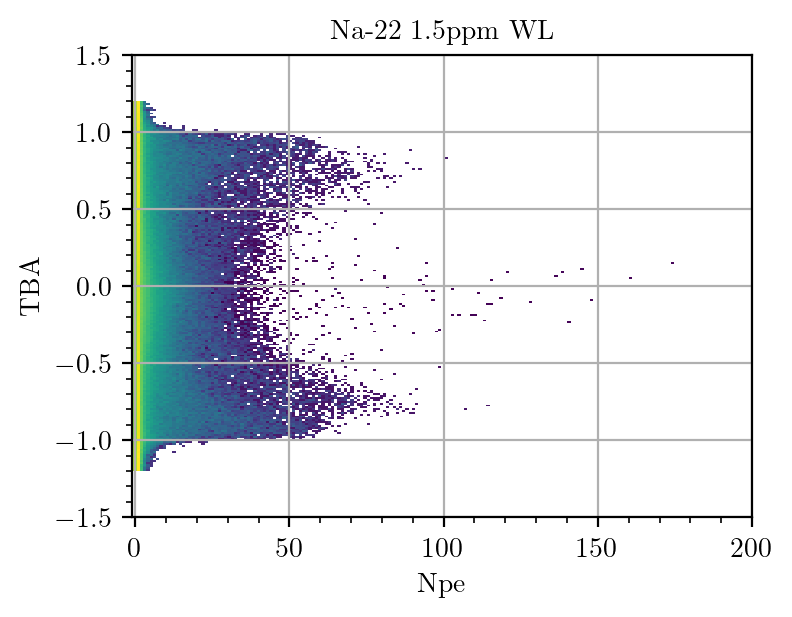

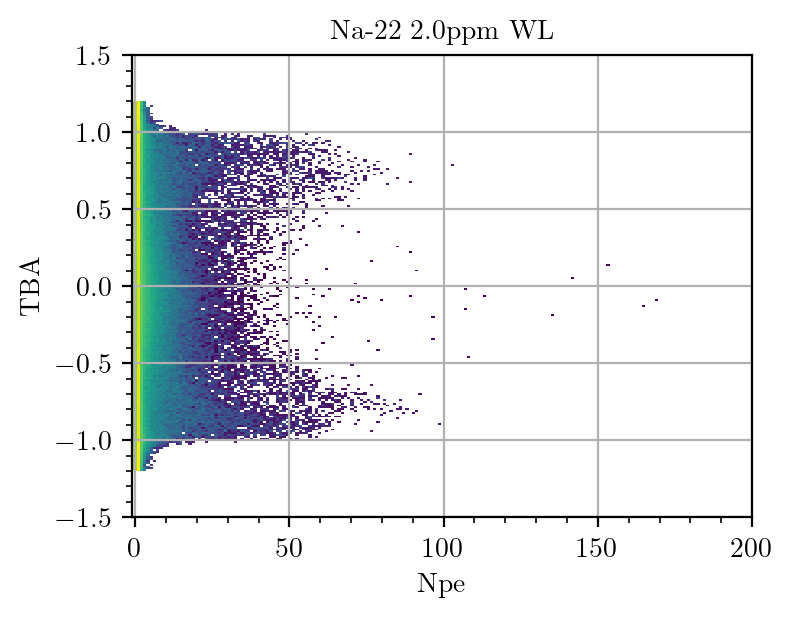

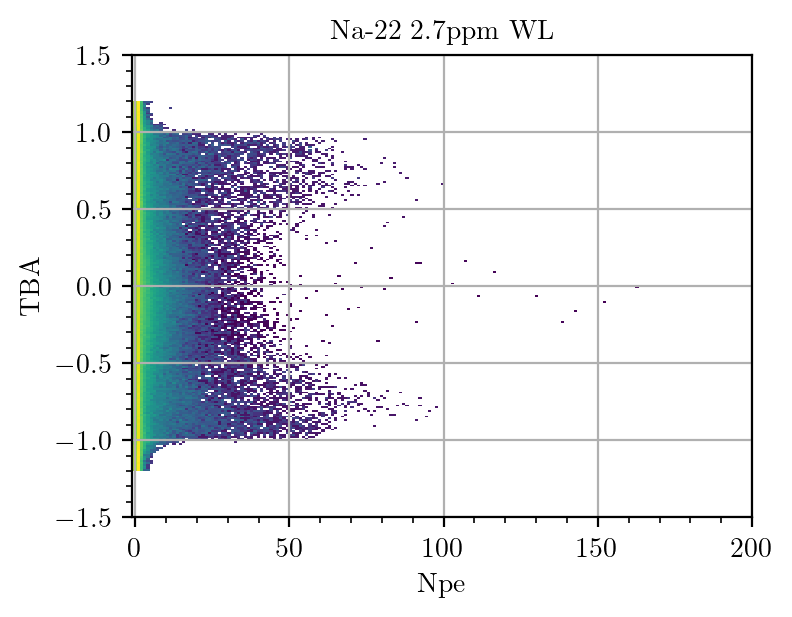

In [ ]:
# Produce TBA 2D histograms
binsx = 200
range_minx = -10
range_maxx = 200
binsy = 200
range_miny = -1.2
range_maxy = 1.2

for i,c in enumerate(cond):
	plt.figure(i)
	filt = data[c]['bsl_filt'] & (data[c]['amplitude_1']<1200) & (data[c]['amplitude_2']<1200) & (data[c]['amplitude_4']<1200) & (data[c]['amplitude_7']<1200)
	h = np.histogram2d(data[c][filt]['pe_10p00us_wl'],data[c][filt]['tba'],bins=[binsx,binsy], range=[[range_minx,range_maxx],[range_miny,range_maxy]])
	plt.pcolormesh(h[1],h[2],np.log10(h[0]/(h[0].sum(axis=0))[np.newaxis,:]).T)
	plt.xlabel('Npe')
	plt.ylabel('TBA')
	plt.title(f'{c} WL')
	plt.xlim(-1,200)
	plt.grid()

## $N_{pe}$ Spectra

In [15]:
# Initialize container
spectra = {}
window = ['yes', 'no']
for c in cond:
    spectra[c] = {}
    for w in window:
        spectra[c][w] = {}

In [16]:
for c in cond:
    for w in window:
        if w=='yes':
            range_min = -10
            range_max = 1000
            nbins = 500
        elif w=='no':
            range_min = -10
            range_max = 2000
            nbins = 500
        filt = data[c]['bsl_filt'] & (data[c]['fprompt']>0.05) & (np.abs(data[c]['tba'])<0.3)
        spectra[c][w]['counts'], spectra[c][w]['bins'] = np.histogram(
            data[c]['pe_10p00us_wl'][filt] if w=='no' else data[c]['pe_10p00us_ww'][filt], 
            bins=nbins, range=(range_min, range_max)
        )
        spectra[c][w]['errs'] = np.sqrt(spectra[c][w]['counts'])

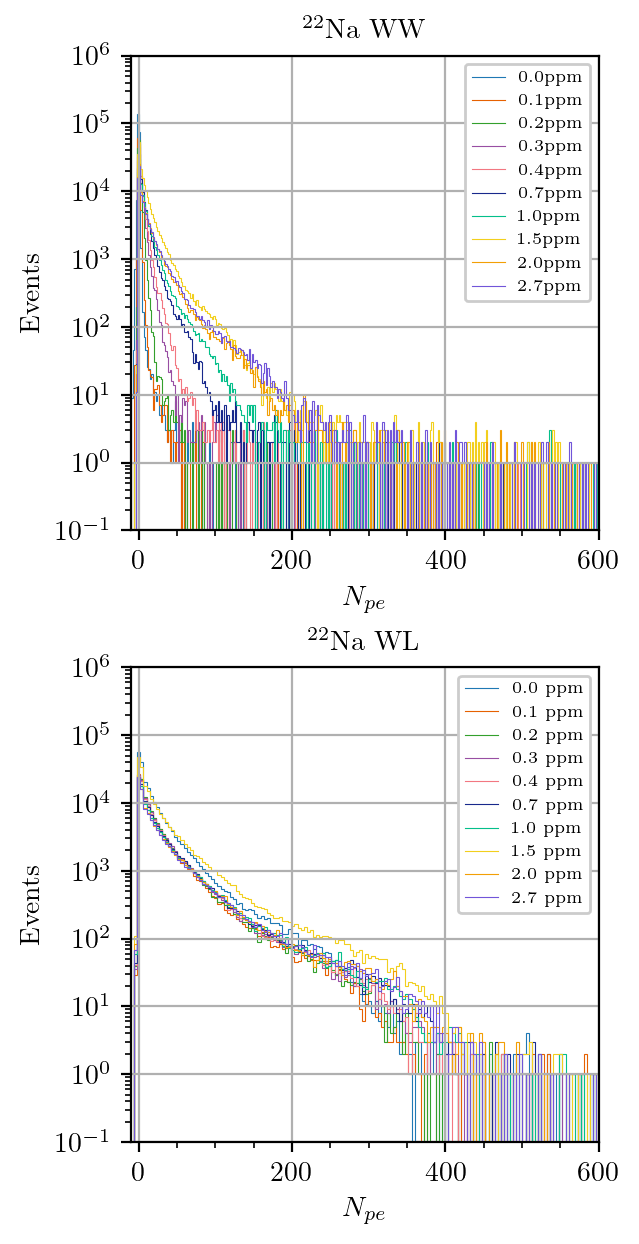

In [17]:
# Make plots for all datasets
# With source, without source, and background subtracted
fig, axs = plt.subplots(2, 1, sharex=False, sharey=False)
fig.set_size_inches(3, 6)
fig.tight_layout(h_pad=3)
for j, w in enumerate(window):
	for i, c in enumerate(cond):
		xe = float(c.split(' ')[1].split('ppm')[0])
		if w=='yes':
			bw = spectra[c][w]['bins'][1]-spectra[c][w]['bins'][0]
			axs[j].stairs(
				spectra[c][w]['counts'], spectra[c][w]['bins'], 
				label=f'{xe}ppm', color=f'C{i}', linewidth=0.4
			)
		else:
			bw = spectra[c][w]['bins'][1]-spectra[c][w]['bins'][0]
			axs[j].stairs(
				spectra[c][w]['counts'], spectra[c][w]['bins'], 
				label=f'{xe} ppm', color=f'C{i}', linewidth=0.4
			)
	axs[j].legend(loc='upper right',fontsize=6)
	axs[j].set_ylim(1e-1, 1e6)
	axs[j].set_xlim(-10,600)
	axs[j].set_yscale('log')
	axs[j].set_title(r'$^{22}\rm Na$ ' + ('WL' if w=='no' else 'WW'))
	axs[j].set_xlabel(r'$N_{pe}$')
	axs[j].set_ylabel('Events')

## Spectrum Fitting

Na-22 0ppm WW MC fit failed
Na-22 0.1ppm WW [1.12994097e+05 9.44068172e-03]
Na-22 0.2ppm WW [1.05017688e+05 2.58644816e-02]
Na-22 0.3ppm WW [1.79722529e+05 4.54001525e-02]
Na-22 0.4ppm WW [1.96398346e+05 6.11872751e-02]
Na-22 0.7ppm WW [2.01993081e+05 1.10780439e-01]
Na-22 1.0ppm WW [1.71481968e+05 1.61920952e-01]
Na-22 1.5ppm WW [3.43892809e+05 2.11028429e-01]
Na-22 2.0ppm WW [1.91050887e+05 2.33127041e-01]
Na-22 2.7ppm WW [2.29425687e+05 2.50289404e-01]
Na-22 0ppm WL [9.53514303e+05 3.69147024e-01]
Na-22 0.1ppm WL [4.71880702e+05 3.90932258e-01]
Na-22 0.2ppm WL [4.85327635e+05 4.05396330e-01]
Na-22 0.3ppm WL [4.33703012e+05 4.38095165e-01]
Na-22 0.4ppm WL [5.19263716e+05 4.22371265e-01]
Na-22 0.7ppm WL [4.43909450e+05 4.67383858e-01]
Na-22 1.0ppm WL [4.41340197e+05 4.69726957e-01]
Na-22 1.5ppm WL [9.68968477e+05 4.78093643e-01]
Na-22 2.0ppm WL [4.82487364e+05 4.75222120e-01]
Na-22 2.7ppm WL [4.81403554e+05 4.76477018e-01]


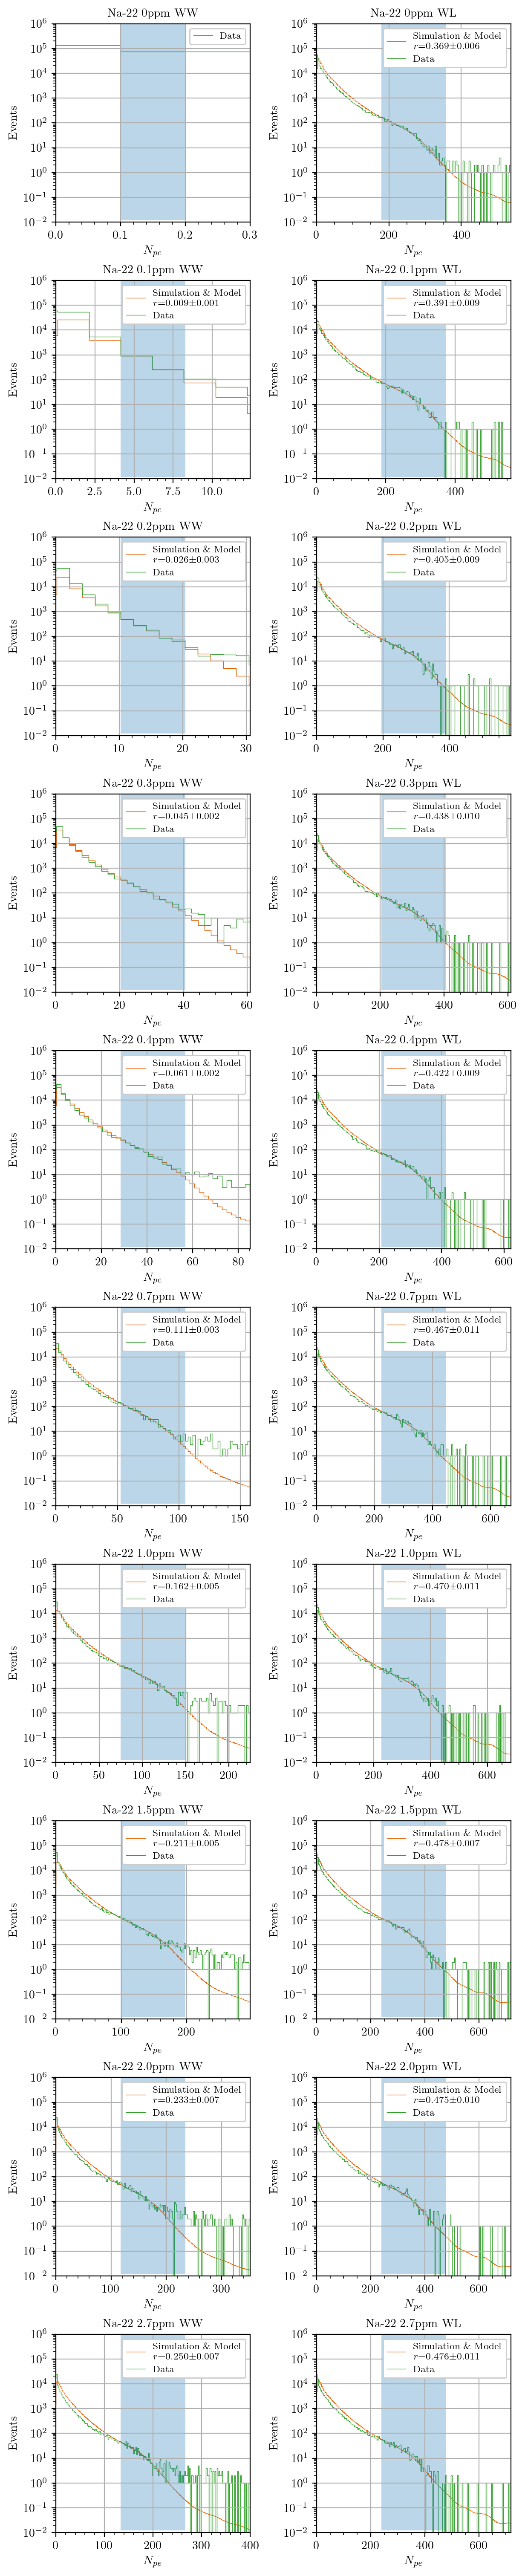

In [18]:
ly = {}
ly_err = {}
fig, axs = plt.subplots(len(cond), 2, sharex=False, sharey=False)
fig.set_size_inches(6, 3*len(cond))
fig.tight_layout(h_pad=3, w_pad=3)

for i,w in enumerate(window):
	ly[w] = []
	ly_err[w] = []
	for k,c in enumerate(cond):
		if w=='yes':
			left=spectra[c][w]['bins'][np.sum(np.cumsum(spectra[c][w]['counts'])/np.sum(spectra[c][w]['counts'])<0.99)]
			right=left*2
		else:
			left=spectra[c][w]['bins'][np.sum(np.cumsum(spectra[c][w]['counts'])/np.sum(spectra[c][w]['counts'])<0.99)]
			right=left*2
		fit_range = (left,right)
		bincen = (spectra[c][w]['bins'][1:]+spectra[c][w]['bins'][:-1])/2
		mask = (bincen<right) & (bincen>left)
		ymin, ymax = 1e-2,1e6
  
		# MC spectrum fit
		try:
			smear = spectrum.DetectorSmearing(
       			fano=np.mean(calib[98]['fano'][[1,2,4,7]]) if w=='no' else np.mean(calib[98]['fano'][[0,3,6]]),
                hist_in=hist_sim['Na-22'])
			par,cov = smear.fit_to_data(
				data=(spectra[c][w]['counts'],spectra[c][w]['bins']),
				sigma=spectra[c][w]['errs'],
				x0=[5e5,(left+right)/2/1000],
				fit_range=fit_range
			)
			par_err = np.array([func.error_distance(df=2, sigma=1)*cov[j,j]**0.5 for j in range(len(par))])
			print(f'{c} '+('WL' if w=='no' else 'WW')+f' {par}')
			ly[w].append(par[1])
			ly_err[w].append(par_err[1])
			axs[k,i].stairs(*(smear.get_spectrum(spectra[c][w]['bins'],*par)), label='Simulation \& Model\n'+r'$r$='+f'{par[1]:.3f}'+r'$\pm$'+f'{par_err[1]:.3f}', color='C1', linewidth=0.5)
		except:
			print(f'{c} '+('WL' if w=='no' else 'WW')+' MC fit failed')
			ly[w].append(np.nan)
			ly_err[w].append(np.nan)
   
		axs[k,i].stairs(spectra[c][w]['counts'],spectra[c][w]['bins'], label='Data', color='C2', linewidth=0.5)
		axs[k,i].axvspan(*fit_range,ymin,ymax,alpha=0.3)
		axs[k,i].set_yscale('log')
		axs[k,i].set_ylim(ymin,ymax)
		axs[k,i].set_xlim(0,right*1.5)
		axs[k,i].legend(loc='upper right')
		axs[k,i].set_title(f'{c} ' + ('WL' if w=='no' else 'WW'))
		axs[k,i].set_xlabel(r'$N_{pe}$')
		axs[k,i].set_ylabel(f'Events')

(0.0, 2.0)

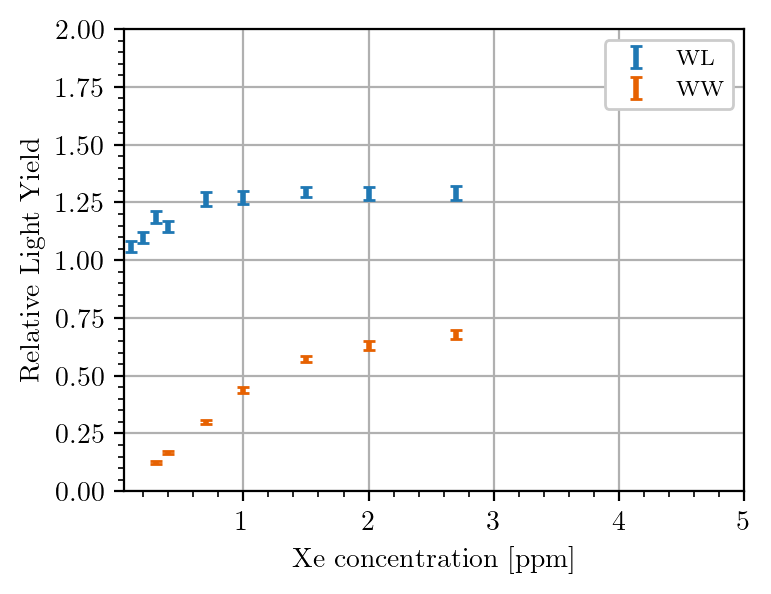

In [19]:
xe_arr = np.array(xe_conc)[1:]
ly_arr = np.array(ly['no'])[1:]/ly['no'][0]
ly_err_arr = np.array(ly_err['no'])[1:]/ly['no'][0]
ly_w_arr = np.array(ly['yes'])[1:]/ly['no'][0]
ly_w_err_arr = np.array(ly_err['yes'])[1:]/ly['no'][0]
plt.errorbar(y=ly_arr,x=xe_arr,yerr=ly_err_arr,label='WL',linestyle='')
plt.errorbar(y=ly_w_arr[2:],x=xe_arr[2:],yerr=ly_w_err_arr[2:],label='WW',linestyle='')
plt.xlabel('Xe concentration [ppm]')
plt.ylabel('Relative Light Yield')
plt.legend(loc='upper right')
plt.xlim(0.05,5)
plt.ylim(0,2)

In [20]:
df = pd.DataFrame({
	'Xe ppm': xe_arr,
	'Ly WL': ly_arr,
	'Ly err WL': ly_err_arr,
	'Ly WW': ly_w_arr,
	'Ly err WW': ly_w_err_arr
})
df.to_csv('/home/as111/sipm-analysis/light_yield_ratio_liq7.csv', index=False)

## Combine Run 1 and Run 2 Light Yield

In [21]:
df1 = pd.read_csv('/home/as111/sipm-analysis/light_yield_ratio_liq6.csv')
df2 = pd.read_csv('/home/as111/sipm-analysis/light_yield_ratio_liq7.csv')

(0.05, 50)

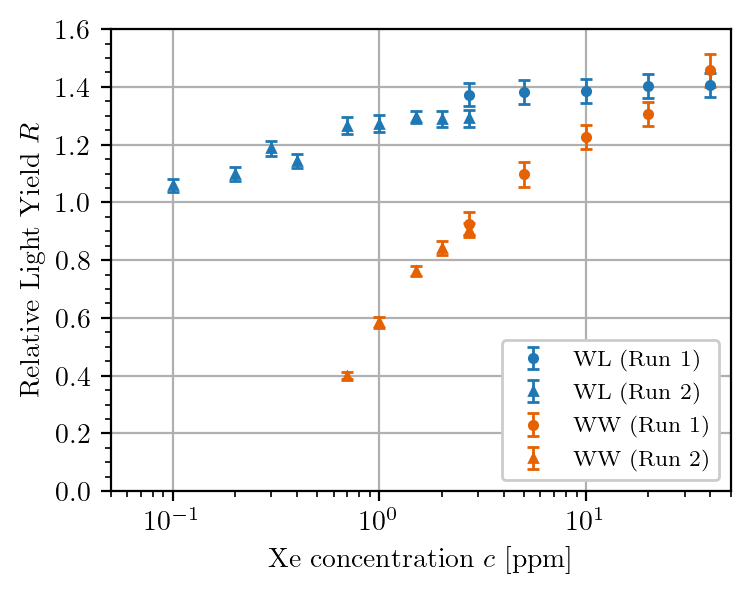

In [22]:
plt.errorbar(df1['Xe ppm'], df1['Ly WL'], yerr=df1['Ly err WL'], fmt='o', label='WL (Run 1)', color='C0', markersize=3, lw=1)
plt.errorbar(df2['Xe ppm'], df2['Ly WL'], yerr=df2['Ly err WL'], fmt='^', label='WL (Run 2)', color='C0', markersize=3, lw=1)
plt.errorbar(df1['Xe ppm'], df1['Ly WW']*4/3, yerr=df1['Ly err WW']*4/3, fmt='o', label='WW (Run 1)', color='C1', markersize=3, lw=1)
plt.errorbar(df2['Xe ppm'][4:], df2['Ly WW'][4:]*4/3, yerr=df2['Ly err WW'][4:]*4/3, fmt='^', label='WW (Run 2)', color='C1', markersize=3, lw=1)
plt.xlabel(r'Xe concentration $c$ [ppm]')
plt.ylabel(r'Relative Light Yield $R$')
plt.legend(loc='lower right')
plt.xscale('log')
plt.ylim(0,1.6)
plt.xlim(0.05,50)

## Singlet Component

In [23]:
# Initialize container
spectra_s = {}
for c in cond:
    spectra_s[c] = {}

In [26]:
for c in cond:
	range_min = -10
	range_max = 500
	nbins = 500
	filt = data[c]['bsl_filt'] & (data[c]['fprompt']>0.05) & (np.abs(data[c]['tba'])<0.3)
	spectra_s[c]['counts'], spectra_s[c]['bins'] = np.histogram(
		data[c]['pe_0p30us_wl'][filt],
		bins=nbins, range=(range_min, range_max)
	)
	spectra_s[c]['errs'] = np.sqrt(spectra_s[c]['counts'])

Text(0, 0.5, 'Events')

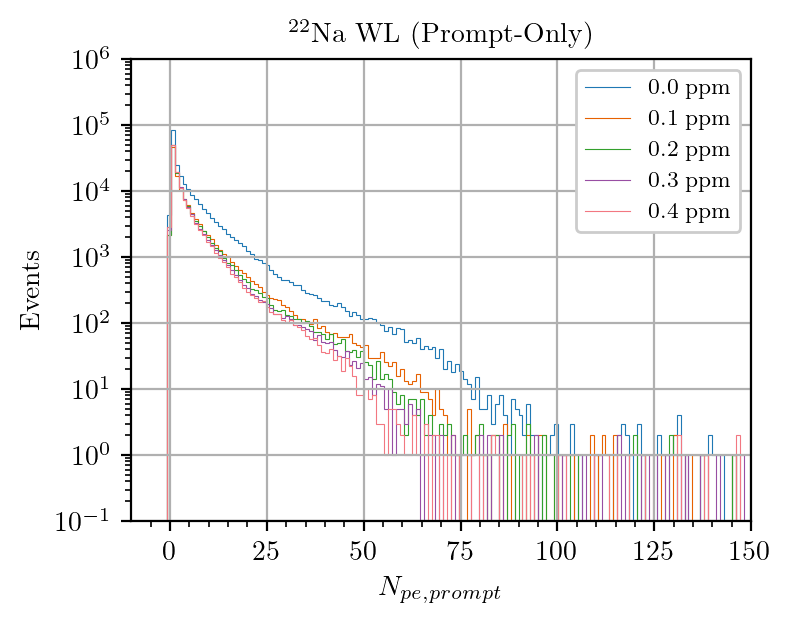

In [28]:
# Make plots for all datasets
for i, c in enumerate(cond):
	xe = float(c.split(' ')[1].split('ppm')[0])
	if xe>0.4:
		continue
	bw = spectra[c][w]['bins'][1]-spectra[c][w]['bins'][0]
	plt.stairs(
		spectra_s[c]['counts'], spectra_s[c]['bins'], 
		label=f'{xe} ppm', color=f'C{i}', linewidth=0.4
	)
plt.legend(loc='upper right')
plt.ylim(1e-1, 1e6)
plt.xlim(-10,150)
plt.yscale('log')
plt.title(r'$^{22}\rm Na$ WL (Prompt-Only)')
plt.xlabel(r'$N_{pe,prompt}$')
plt.ylabel('Events')